# High-freq bouts — clean computational pipeline

Mirror of `alarm_bouts_2.ipynb` but for `event_type == "high-freq"`.
Top half builds reusable DataFrames once; later cells slice them.

After the load + bout-detection cell, every row in `hf` carries:
- `bout_id` — unique per consecutive run within `(date_folder, exp, assigned_location)`, gap ≤ `ICI_HIGH_FREQ_BOUT_THRESHOLD_S`.
- `bout_size` — total calls in that bout (broadcast to every row).
- `position` — chronological position within the bout (1 = first call).

## Setup

In [1]:
# === Cell: setup ===
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PARQUET_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")
FIGURES_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/high_freq")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]
# Bout-defining ICI range. A pair of consecutive calls counts as "same bout"
# only if their gap is in [MIN_ICI_BOUT_S, MAX_ICI_BOUT_S]. Sub-MIN gaps are
# probably artifacts (overlap from two animals, or one call split in two);
# above MAX is a between-bout silence.
MIN_ICI_BOUT_S = 0.05   
MAX_ICI_BOUT_S = 0.2    # 200 ms — empirical dip after the 100 ms mode
ICI_HIGH_FREQ_BOUT_THRESHOLD_S = MAX_ICI_BOUT_S   # backwards-compat alias
MIN_BOUT_SIZE = 2                      # bouts_meta keeps only bouts with >= this many calls

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")

## Load high-freq calls with bout annotations

In [2]:
# === Cell: load_high_freq_and_detect_bouts ===
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"] == "high-freq"]
    parts.append(df_d)
hf = pd.concat(parts, ignore_index=True)

hf = hf.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

prev_stop = hf.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
gaps = hf["start_time_real"] - prev_stop
is_new_bout = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_HIGH_FREQ_BOUT_THRESHOLD_S))

hf["bout_id"]   = is_new_bout.cumsum()
hf["bout_size"] = hf.groupby("bout_id")["bout_id"].transform("size")
hf["position"]  = hf.groupby("bout_id").cumcount() + 1

print(f"{len(hf):,} high-freq calls in {hf['bout_id'].nunique():,} bouts")
hf.head(3)

448,089 high-freq calls in 315,640 bouts


,exp,file_num,event_type,start_time_file_sec,stop_time_file_sec,duration_sec,assigned_location,channel,meanprob_noise,meanprob_alarm,...,meanprob_warble,start_time_experiment_sec,stop_time_experiment_sec,start_time_real,stop_time_real,date_folder,day_in_experiment,bout_id,bout_size,position
0,235,0,high-freq,224.108928,224.154872,0.045944,arena_1,10,0.0,0.054327,...,0.244462,224.108928,224.154872,2025-03-21 19:38:34.108928,2025-03-21 19:38:34.154872,2025_03,1,1,1,1
1,235,0,high-freq,225.018368,225.048440,0.030072,arena_1,10,0.0,0.007981,...,0.407156,225.018368,225.048440,2025-03-21 19:38:35.018368,2025-03-21 19:38:35.048440,2025_03,1,2,1,1
2,235,0,high-freq,242.768640,242.818936,0.050296,arena_1,10,0.0,0.029809,...,0.324752,242.768640,242.818936,2025-03-21 19:38:52.768640,2025-03-21 19:38:52.818936,2025_03,1,3,1,1


## Inter-call silent gap

Per-call silent gap = `this.start - prev.stop` within `(date_folder, exp, assigned_location)`.
Used to decide `ICI_HIGH_FREQ_BOUT_THRESHOLD_S`. Plotted on a log time axis with shared bins per date so the panels are comparable.

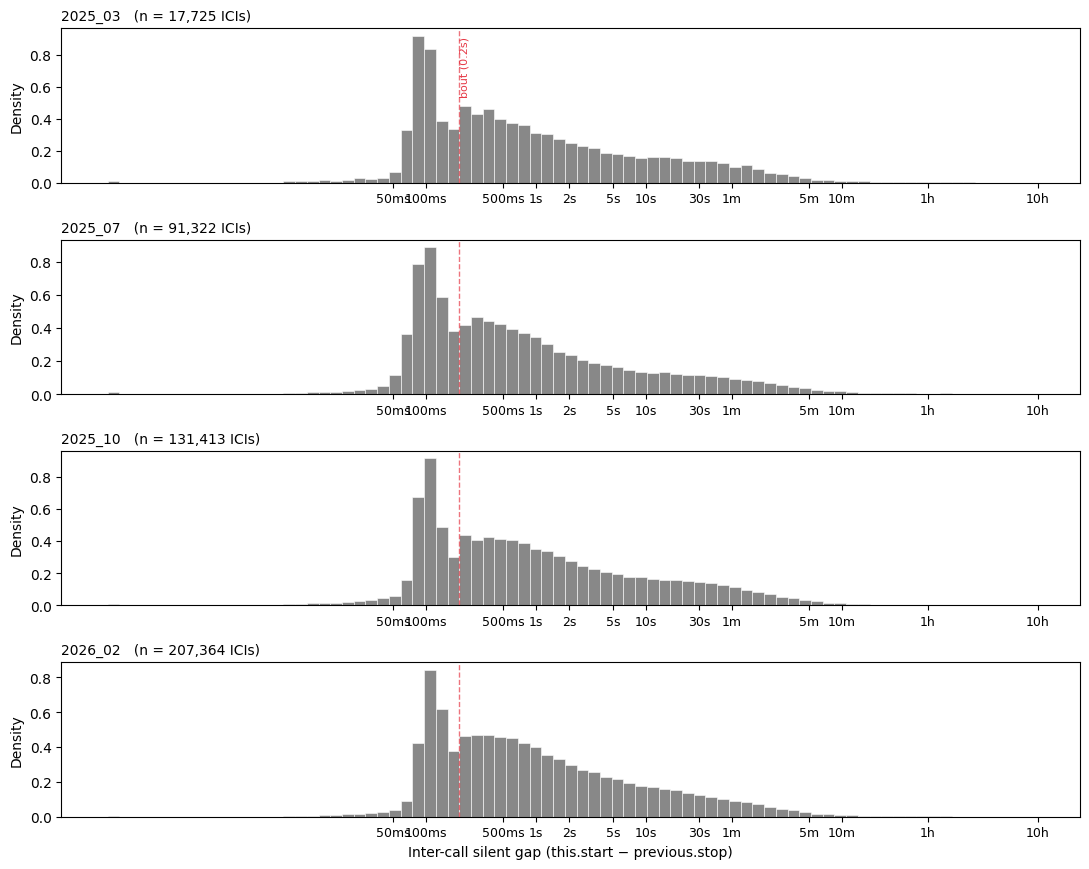

In [9]:
# === Cell: plot_ici_distribution_per_date ===
prev_stop = hf.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
hf_ici = pd.DataFrame({
    "date_folder": hf["date_folder"],
    "ici_s":       (hf["start_time_real"] - prev_stop).dt.total_seconds(),
}).dropna()
hf_ici = hf_ici[hf_ici["ici_s"] > 0]

# Shared log-bins so panels are comparable.
log_ici_all = np.log10(hf_ici["ici_s"])
bins = np.linspace(log_ici_all.min(), log_ici_all.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = hf_ici[hf_ici["date_folder"] == date_tag]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no ICIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    log_sub = np.log10(sub["ici_s"])
    ax.hist(log_sub, bins=bins, density=True, color="#888888",
            edgecolor="white", linewidth=0.4)

    ax.axvline(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), color="#E63946",
               linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} ICIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.tick_params(labelbottom=True)

# Tick labels on every panel.
tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h", "10h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[0].text(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), axes[0].get_ylim()[1] * 0.95,
             f"  bout ({ICI_HIGH_FREQ_BOUT_THRESHOLD_S}s)",
             rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Inter-call silent gap (this.start − previous.stop)")
fig.tight_layout()
save_fig(fig, "high_freq_ici_distribution_per_date")
plt.show()

## high freq with warbles



In [2]:
# === Cell: prep_merged_hf_warble_bouts ===
# 1) Load HF + warble together.
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"].isin(["high-freq", "warble"])]
    parts.append(df_d)
hf_w = pd.concat(parts, ignore_index=True)

# 2) Sort within (date, exp, location), compute per-call silent gap.
hf_w = hf_w.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

grp = hf_w.groupby(["date_folder", "exp", "assigned_location"])
prev_stop  = grp["stop_time_real"].shift(1)
prev_start = grp["start_time_real"].shift(1)

# Two flavors of inter-call interval:
#   ici_s        — silent gap (this.start - prev.stop). Bout-detection threshold.
#   ici_period_s — start-to-start period (this.start - prev.start). 1/period = Hz.
hf_w["ici_s"]        = (hf_w["start_time_real"] - prev_stop ).dt.total_seconds()
hf_w["ici_period_s"] = (hf_w["start_time_real"] - prev_start).dt.total_seconds()

# 3) Define merged bouts: gap must be in [MIN_ICI_BOUT_S, MAX_ICI_BOUT_S]
#    to count as same-bout. Outside that range starts a new bout.
is_new_bout = (
    hf_w["ici_s"].isna()
    | (hf_w["ici_s"] > MAX_ICI_BOUT_S)
    | (hf_w["ici_s"] < MIN_ICI_BOUT_S)
)
hf_w["merged_bout_id"] = is_new_bout.cumsum()

# 4) Per-bout summary.
merged_bouts = hf_w.groupby("merged_bout_id").agg(
    date_folder=("date_folder", "first"),
    n_calls=("event_type", "size"),
    n_hf=("event_type", lambda s: (s == "high-freq").sum()),
    n_w=("event_type",  lambda s: (s == "warble").sum()),
)
merged_bouts["frac_hf"] = merged_bouts["n_hf"] / merged_bouts["n_calls"]

print(f"{len(hf_w):,} HF+W calls, {len(merged_bouts):,} merged bouts "
      f"({(merged_bouts['n_calls'] >= MIN_BOUT_SIZE).sum():,} with >= {MIN_BOUT_SIZE} calls)")

1,123,318 HF+W calls, 754,175 merged bouts (202,979 with >= 2 calls)


## Categorize bouts: HF-containing vs pure warble

A merged bout is **`hf`** if at least `MIN_HF_FRAC` of its calls are high-freq
(default 0.5 — majority rule), otherwise **`warble`**. This avoids
mislabeling a mostly-warble bout as HF just because one stray call was tagged
as HF. The within-bout rhythm is shared between the two categories, so this
is the natural functional split.

After this cell:
- `bouts` — one row per multi-call merged bout, with `category`, `n_calls`, `n_hf`, `n_w`, `frac_hf`, `date_folder`.
- `hf_w["bout_category"]` — per-call tag, so any per-call slice (`hf_w[hf_w["bout_category"] == "hf"]`) is one mask away.

In [3]:
# === Cell: categorize_bouts_hf_vs_warble ===
# Tag each merged bout as hf (any HF) or warble (none).
# Majority rule: an "hf" bout is one where >= MIN_HF_FRAC of calls are HF.
# (50/50 bouts go to "hf" by default — flip to > to send them to "warble".)
MIN_HF_FRAC = 0.5
merged_bouts["category"] = np.where(merged_bouts["frac_hf"] >= MIN_HF_FRAC, "hf", "warble")

# One row per multi-call merged bout — drop singletons.
bouts = merged_bouts[merged_bouts["n_calls"] >= MIN_BOUT_SIZE].copy()

# Map category back to per-call rows (every call inherits its bout's category).
hf_w["bout_category"] = hf_w["merged_bout_id"].map(merged_bouts["category"])

print(f"{len(bouts):,} multi-call bouts (>= {MIN_BOUT_SIZE} calls)")
print()
print("By category:")
print(bouts["category"].value_counts())
print()
print("Per-date breakdown:")
print(bouts.groupby(["date_folder", "category"]).size().unstack(fill_value=0))

202,979 multi-call bouts (>= 2 calls)

By category:
category
hf        104446
warble     98533
Name: count, dtype: int64

Per-date breakdown:
category        hf  warble
date_folder               
2025_03       3596    2018
2025_07      19513   15284
2025_10      29913   22194
2026_02      51424   59037


## Within-bout ICI: HF vs warble category

Per-date overlay of within-bout ICI density for HF-containing bouts vs pure
warble bouts.

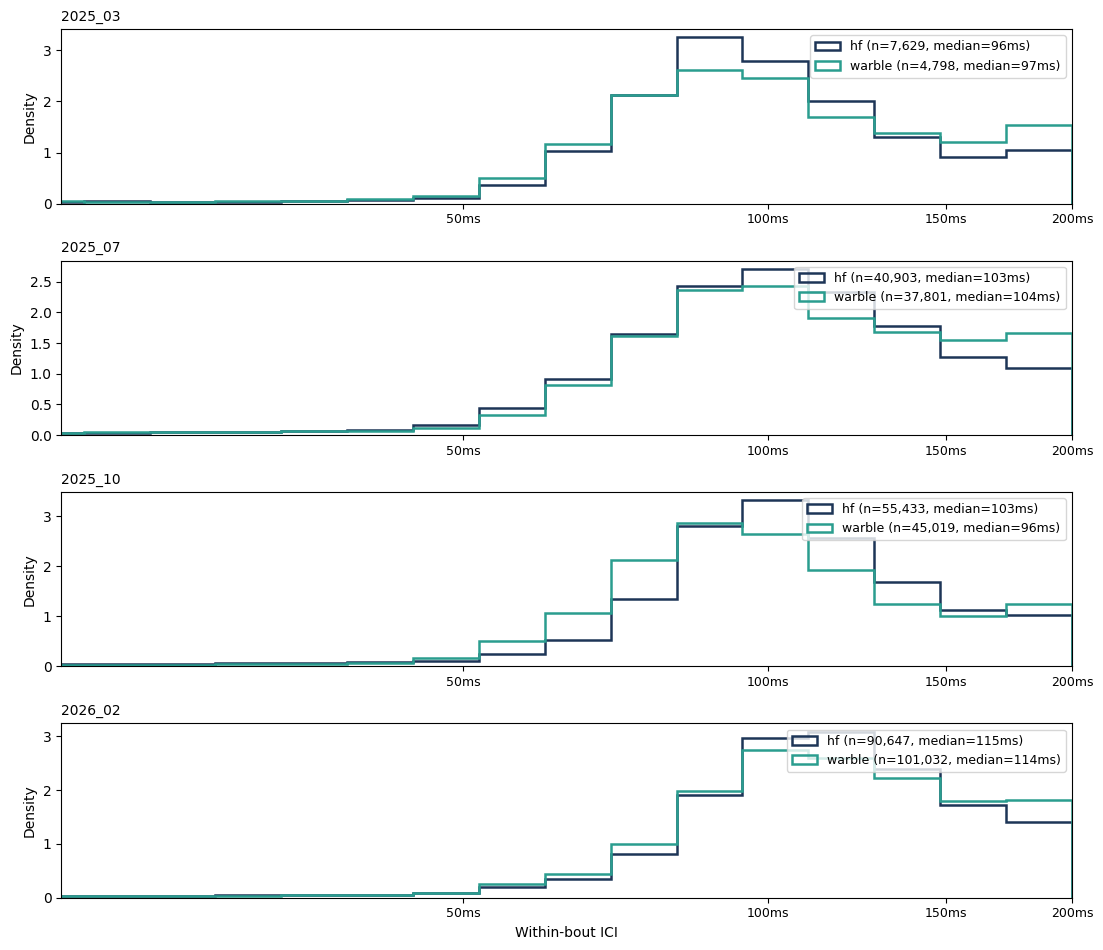

In [5]:
# === Cell: plot_within_bout_ici_hf_vs_warble ===
# Within-bout ICIs in multi-call merged bouts, tagged by category.
within = hf_w[
    hf_w["merged_bout_id"].isin(bouts.index)
    & hf_w["ici_s"].notna()
    & (hf_w["ici_s"] > 0)
    & (hf_w["ici_s"] <= ICI_HIGH_FREQ_BOUT_THRESHOLD_S)
]

CATEGORIES = [
    ("hf",     "#1D3557"),
    ("warble", "#2A9D8F"),
]

log_ici = np.log10(within["ici_s"])
bins = np.linspace(log_ici.min(), log_ici.max(), 50)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.4 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = within[within["date_folder"] == date_tag]
    if sub.empty:
        ax.set_axis_off()
        continue
    for cat, color in CATEGORIES:
        s = sub[sub["bout_category"] == cat]["ici_s"]
        if s.empty:
            continue
        ax.hist(np.log10(s), bins=bins, density=True,
                histtype="step", color=color, linewidth=1.8,
                label=f"{cat} (n={len(s):,}, median={s.median()*1000:.0f}ms)")

    ax.set_title(date_tag, loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(labelbottom=True)
    ax.set_xlim(np.log10(0.02), np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S))

tick_seconds = [0.05, 0.1, 0.15, 0.2]
tick_labels  = ["50ms", "100ms", "150ms", "200ms"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[-1].set_xlabel("Within-bout ICI")
fig.tight_layout()
save_fig(fig, "within_bout_ici_hf_vs_warble_per_date")
plt.show()

## Within-bout calling rate (period → Hz)

Same data as the within-bout ICI plot, but in **start-to-start period**
units. `1 / median(period) = within-bout calling rate in Hz` — the right
number to quote in the abstract.

In [ ]:
# === Cell: plot_within_bout_period_hf_vs_warble ===
# Within-bout periods (start-to-start) in multi-call merged bouts, by category.
# Use within-bout boundary on silent gap (so we keep the same bout structure),
# and read the period column for the rhythm measure.
within = hf_w[
    hf_w["merged_bout_id"].isin(bouts.index)
    & hf_w["ici_s"].notna()
    & (hf_w["ici_s"] > 0)
    & (hf_w["ici_s"] <= MAX_ICI_BOUT_S)
    & (hf_w["ici_period_s"] > 0)
]

CATEGORIES = [
    ("hf",     "#1D3557"),
    ("warble", "#2A9D8F"),
]

log_p = np.log10(within["ici_period_s"])
bins = np.linspace(log_p.min(), log_p.max(), 60)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.4 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

summary_rows = []
for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = within[within["date_folder"] == date_tag]
    if sub.empty:
        ax.set_axis_off()
        continue
    for cat, color in CATEGORIES:
        s = sub[sub["bout_category"] == cat]["ici_period_s"]
        if s.empty:
            continue
        med_s  = s.median()
        med_hz = 1.0 / med_s
        summary_rows.append({"date_folder": date_tag, "category": cat,
                             "n": len(s), "median_period_s": round(med_s, 3),
                             "median_rate_hz": round(med_hz, 2)})
        ax.hist(np.log10(s), bins=bins, density=True,
                histtype="step", color=color, linewidth=1.8,
                label=f"{cat} (n={len(s):,}, median={med_s*1000:.0f}ms = {med_hz:.1f}Hz)")

    ax.set_title(date_tag, loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(labelbottom=True)

tick_seconds = [0.1, 0.15, 0.2, 0.3, 0.5]
tick_labels  = ["100ms\n(10Hz)", "150ms\n(6.7Hz)", "200ms\n(5Hz)",
                "300ms\n(3.3Hz)", "500ms\n(2Hz)"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=8)

axes[-1].set_xlabel("Within-bout start-to-start period")
fig.tight_layout()
save_fig(fig, "within_bout_period_hf_vs_warble_per_date")
plt.show()

print()
print("=== Median within-bout rate (start-to-start period) ===")
print(pd.DataFrame(summary_rows).to_string(index=False))

## Bout-size distribution: HF vs warble category

Per-date overlay of the number-of-calls-per-bout distribution for HF bouts
vs warble bouts.

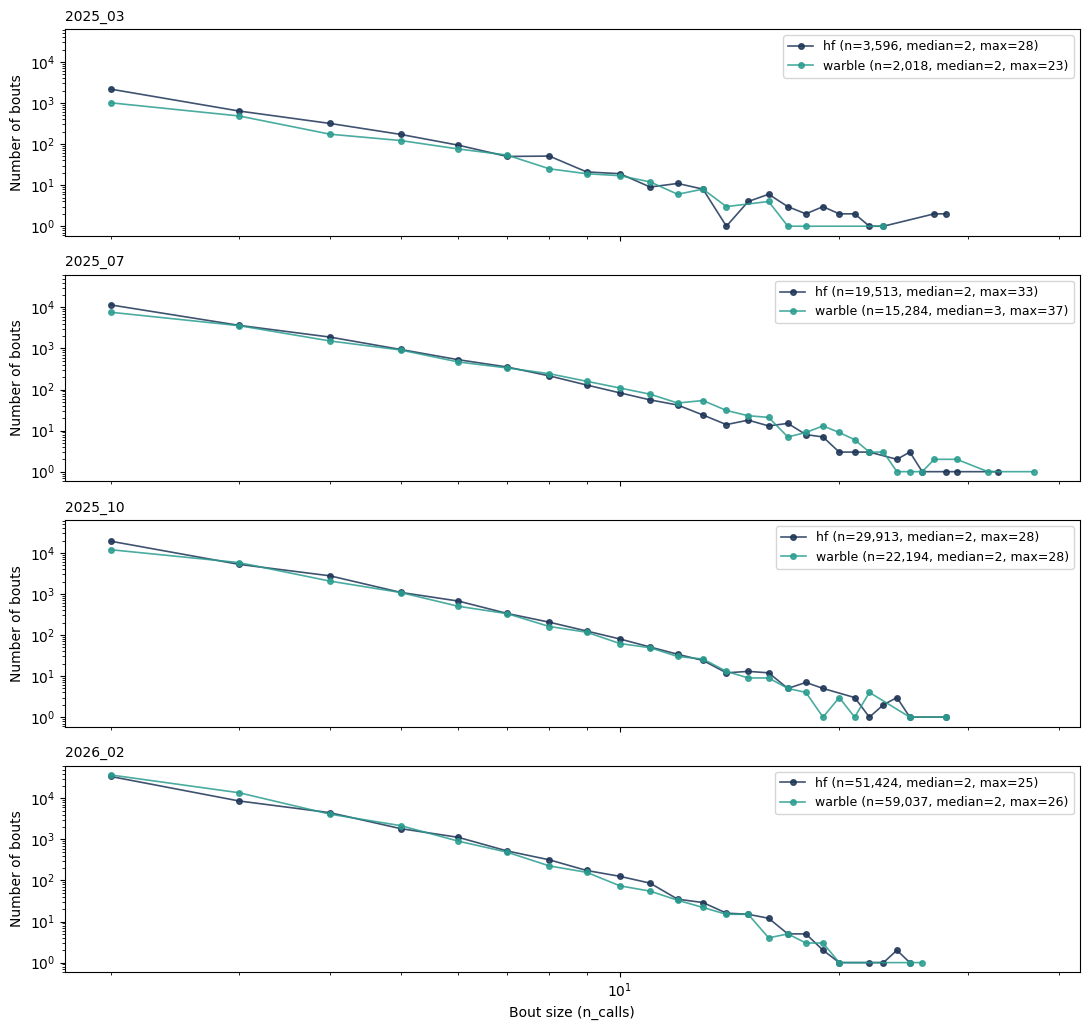

In [6]:
# === Cell: plot_bout_size_hf_vs_warble ===
CATEGORIES = [
    ("hf",     "#1D3557"),
    ("warble", "#2A9D8F"),
]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.6 * len(DATES_TO_PLOT)),
    sharex=True, sharey=True,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts[bouts["date_folder"] == date_tag]
    if sub.empty:
        ax.set_axis_off()
        continue
    for cat, color in CATEGORIES:
        s = sub[sub["category"] == cat]["n_calls"]
        if s.empty:
            continue
        sizes = s.value_counts().sort_index()
        ax.plot(sizes.index, sizes.values, marker="o", linestyle="-",
                color=color, alpha=0.85, markersize=4, linewidth=1.2,
                label=f"{cat} (n={len(s):,}, median={s.median():.0f}, max={s.max()})")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(date_tag, loc="left", fontsize=10)
    ax.set_ylabel("Number of bouts")
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Bout size (n_calls)")
fig.tight_layout()
save_fig(fig, "bout_size_hf_vs_warble_per_date")
plt.show()

## `bouts_meta` — one row per bout

In [4]:
# === Cell: build_bouts_meta ===
# Two per-bout dataframes — one for HF-category bouts, one for warble-category bouts.
# Indexed by merged_bout_id. One row per multi-call merged bout.

# Position within each merged bout (1 = first call).
hf_w["position"] = hf_w.groupby("merged_bout_id").cumcount() + 1

_meta_full = (
    hf_w[hf_w["position"] == 1]
    .set_index("merged_bout_id")
    [[
        "date_folder", "exp", "file_num", "assigned_location",
        "start_time_real", "start_time_file_sec",
        "start_time_experiment_sec", "day_in_experiment",
    ]]
    .join(bouts[["n_calls", "n_hf", "n_w", "frac_hf", "category"]], how="inner")
    .rename(columns={"n_calls": "bout_size"})
)

bouts_meta_hf     = _meta_full[_meta_full["category"] == "hf"].copy()
bouts_meta_warble = _meta_full[_meta_full["category"] == "warble"].copy()

print(f"bouts_meta_hf:     {len(bouts_meta_hf):,} bouts")
print(f"bouts_meta_warble: {len(bouts_meta_warble):,} bouts")

bouts_meta_hf:     104,446 bouts
bouts_meta_warble: 98,533 bouts


## `duration_by_position` — wide-format duration matrix

One row per bout, one column per position, values are call durations (NaN where the bout doesn't have that position). Built once on the full high-freq dataset; per-analysis filtering happens by selecting rows from this matrix.

In [5]:
# === Cell: build_duration_by_position ===
# Two duration-by-position matrices, one per category.
# Index aligns with bouts_meta_<cat>.index. Columns are 1, 2, ... (position).

duration_by_position_hf = (
    hf_w[hf_w["merged_bout_id"].isin(bouts_meta_hf.index)]
    .pivot(index="merged_bout_id", columns="position", values="duration_sec")
)
duration_by_position_warble = (
    hf_w[hf_w["merged_bout_id"].isin(bouts_meta_warble.index)]
    .pivot(index="merged_bout_id", columns="position", values="duration_sec")
)
print(f"duration_by_position_hf:     {duration_by_position_hf.shape[0]:,} × {duration_by_position_hf.shape[1]}")
print(f"duration_by_position_warble: {duration_by_position_warble.shape[0]:,} × {duration_by_position_warble.shape[1]}")

duration_by_position_hf:     104,446 × 33
duration_by_position_warble: 98,533 × 37


## Call duration by position

Violin plots of call duration at each position in the bout, separately for HF
and warble category bouts. Later positions are computed over the smaller
subset of bouts that reach that length.

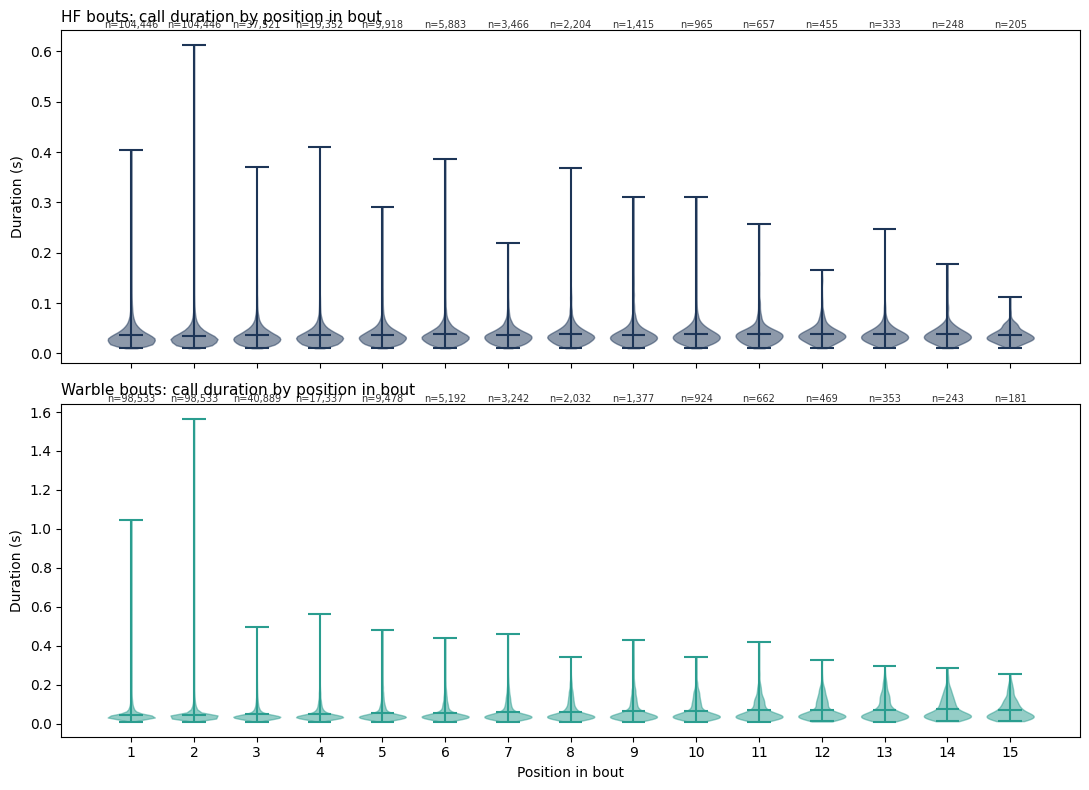

In [8]:
# === Cell: plot_duration_by_position_violin ===
MAX_POS = 15   # cap; raise to push further into the tail

# Singleton durations (1-call merged bouts, by event_type). Pulled from merged_bouts
# (NOT bouts) because bouts is filtered to >= MIN_BOUT_SIZE.
_n_calls = hf_w["merged_bout_id"].map(merged_bouts["n_calls"])
hf_singletons     = hf_w.loc[(_n_calls == 1) & (hf_w["event_type"] == "high-freq"), "duration_sec"].values
warble_singletons = hf_w.loc[(_n_calls == 1) & (hf_w["event_type"] == "warble"),    "duration_sec"].values

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for ax, dbp, singletons, label, color in [
    (axes[0], duration_by_position_hf,     hf_singletons,     "HF bouts",     "#1D3557"),
    (axes[1], duration_by_position_warble, warble_singletons, "Warble bouts", "#2A9D8F"),
]:
    positions, data = [], []
    # Singletons get their own column on the left.
    if len(singletons) >= 5:
        positions.append(0)
        data.append(singletons)
    for pos in range(1, MAX_POS + 1):
        if pos not in dbp.columns:
            continue
        vals = dbp[pos].dropna().values
        if len(vals) < 5:
            continue
        positions.append(pos)
        data.append(vals)
    if not data:
        ax.set_axis_off()
        continue

    parts = ax.violinplot(data, positions=positions, showmeans=True, widths=0.75)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor(color)
    for key in ("cbars", "cmins", "cmaxes", "cmeans"):
        if key in parts:
            parts[key].set_color(color)

    y_top = max(v.max() for v in data) * 1.05
    for pos, vals in zip(positions, data):
        ax.text(pos, y_top, f"n={len(vals):,}", ha="center", va="bottom",
                fontsize=7, color="#333333")

    ax.set_xticks(positions)
    ax.set_xticklabels(["single call" if p == 0 else str(p) for p in positions])
    ax.set_ylabel("Duration (s)")
    ax.set_title(f"{label}: call duration by position in bout", loc="left", fontsize=11)

axes[-1].set_xlabel("Position in bout")
fig.tight_layout()
save_fig(fig, "duration_by_position_violin")
plt.show()